In [1]:
import pandas as pd
import numpy as np
# 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
# 
from sklearn.model_selection import train_test_split
# 
from sklearn.ensemble import RandomForestClassifier
# 
from special_use_classes import OutlierHandling
import special_use_classes
import importlib
importlib.reload(special_use_classes)
# 
from sklearn.metrics import classification_report
# 
import matplotlib.pyplot as plt
import seaborn as sns
# 
# from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import  SMOTENC
outlier_handler = OutlierHandling()
# 
from joblib import dump
# 
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)
pd.options.display.float_format = '{:,.2f}'.format
# 
# colors for plt
color_pastel = sns.color_palette('pastel')
color_deep = sns.color_palette('deep')
color_bright = sns.color_palette('bright')

In [2]:
df = pd.read_csv(r'data\Europe Sales Records.csv')

In [3]:
df.head()

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Europe,Czech Republic,Beverages,Offline,C,9/12/2011,478051030,9/29/2011,4778,47.45,31.79,"226,716.10","151,892.62","74,823.48"
1,Europe,Bosnia and Herzegovina,Clothes,Online,M,10/14/2013,919133651,11/4/2013,927,109.28,35.84,"101,302.56","33,223.68","68,078.88"
2,Europe,Austria,Cereal,Offline,C,8/13/2014,987410676,9/6/2014,5616,205.70,117.11,"1,155,211.20","657,689.76","497,521.44"
3,Europe,Bulgaria,Office Supplies,Online,L,10/31/2010,672330081,11/29/2010,6266,651.21,524.96,"4,080,481.86","3,289,399.36","791,082.50"
4,Europe,Estonia,Fruits,Online,L,9/28/2016,579463422,11/1/2016,4958,9.33,6.92,"46,258.14","34,309.36","11,948.78"


In [4]:
cols_to_drop = ['Region', 'Order ID']
for i in cols_to_drop:
    try:
        df.drop(columns={i}, inplace=True)
        
    except Exception as e:
        print(e)

In [5]:
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Country         1330 non-null   object        
 1   Item Type       1330 non-null   object        
 2   Sales Channel   1330 non-null   object        
 3   Order Priority  1330 non-null   object        
 4   Order Date      1330 non-null   datetime64[ns]
 5   Ship Date       1330 non-null   datetime64[ns]
 6   Units Sold      1330 non-null   int64         
 7   Unit Price      1330 non-null   float64       
 8   Unit Cost       1330 non-null   float64       
 9   Total Revenue   1330 non-null   float64       
 10  Total Cost      1330 non-null   float64       
 11  Total Profit    1330 non-null   float64       
dtypes: datetime64[ns](2), float64(5), int64(1), object(4)
memory usage: 124.8+ KB


In [7]:
df.isna().sum()

Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

In [8]:
df.duplicated().sum()

0

Total Revenue: 102, Total Revenue: 0, Total: 102
________________

Total Cost: 143, Total Cost: 0, Total: 143
________________

Total Profit: 53, Total Profit: 0, Total: 53
________________

None


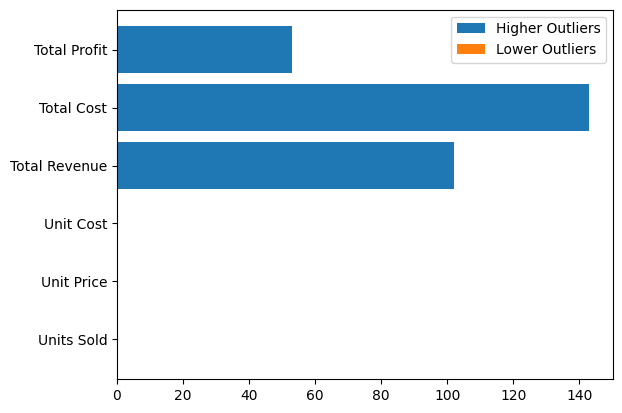

<Axes: >

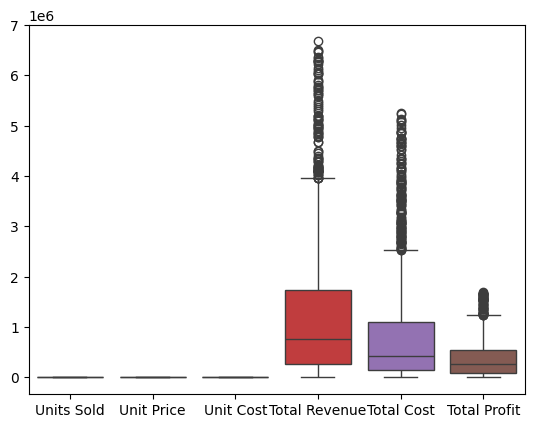

In [9]:
outlier_handler = OutlierHandling()


print(outlier_handler.count_outliers_df(df))
# print(outlier_handler.display_outliers_df(df))
outlier_handler.plot(df)
sns.boxplot(df)

In [10]:
for i in df.select_dtypes('object').columns.tolist():
    print(df[i].unique())
    print('\n\n')


['Czech Republic' 'Bosnia and Herzegovina' 'Austria' 'Bulgaria' 'Estonia'
 'Montenegro' 'Luxembourg' 'Switzerland' 'Finland' 'Belgium' 'San Marino'
 'Netherlands' 'Russia' 'Ukraine' 'Latvia' 'Serbia' 'Portugal' 'Poland'
 'Liechtenstein' 'United Kingdom' 'Slovenia' 'Malta' 'Cyprus' 'Monaco'
 'Norway' 'Armenia' 'Denmark' 'Kosovo' 'Hungary' 'Lithuania' 'Albania'
 'Moldova ' 'France' 'Spain' 'Sweden' 'Macedonia' 'Greece' 'Italy'
 'Germany' 'Andorra' 'Iceland' 'Croatia' 'Slovakia' 'Vatican City'
 'Belarus' 'Ireland' 'Romania' 'Georgia']



['Beverages' 'Clothes' 'Cereal' 'Office Supplies' 'Fruits' 'Vegetables'
 'Meat' 'Snacks' 'Baby Food' 'Household' 'Cosmetics' 'Personal Care']



['Offline' 'Online']



['C' 'M' 'L' 'H']





<p style='color: white; background-color:#5b1f18; padding:10px; border-radius:10px; text-align:center'>lets display the highest revenue in europe</p>

In [11]:
most_valued_country = df.nlargest(10,'Total Revenue')[['Country','Total Revenue']]
print(most_valued_country.head())


         Country  Total Revenue
242   San Marino   6,672,675.95
1040    Portugal   6,510,146.37
19      Portugal   6,483,446.76
122      Croatia   6,468,853.60
1066      Russia   6,359,716.86


san marino tops the sales revenue 

In [12]:
high_revenue_df = df.nlargest(10, 'Total Revenue')
high_revenue_df[['Country','Units Sold', 'Unit Price', 'Total Revenue', 'Total Profit']]



,Country,Units Sold,Unit Price,Total Revenue,Total Profit
242,San Marino,9985,668.27,"6,672,675.95","1,654,814.05"
1040,Portugal,9997,651.21,"6,510,146.37","1,262,121.25"
19,Portugal,9956,651.21,"6,483,446.76","1,256,945.00"
122,Croatia,9680,668.27,"6,468,853.60","1,604,266.40"
1066,Russia,9766,651.21,"6,359,716.86","1,232,957.50"
270,Slovenia,9736,651.21,"6,340,180.56","1,229,170.00"
1306,Netherlands,9691,651.21,"6,310,876.11","1,223,488.75"
974,France,9419,668.27,"6,294,435.13","1,561,010.87"
1025,Czech Republic,9405,668.27,"6,285,079.35","1,558,690.65"
988,Russia,9648,651.21,"6,282,874.08","1,218,060.00"


In [13]:
df['Total Revenue'].max()

6672675.95

In [14]:
# df.groupby('')
df.columns

Index(['Country', 'Item Type', 'Sales Channel', 'Order Priority', 'Order Date',
       'Ship Date', 'Units Sold', 'Unit Price', 'Unit Cost', 'Total Revenue',
       'Total Cost', 'Total Profit'],
      dtype='object')

Country
Albania      524.96
Portugal     524.96
Luxembourg   524.96
Macedonia    524.96
Malta        524.96
Name: Unit Cost, dtype: float64


Text(0.5, 1.0, 'maximum unit price by country')

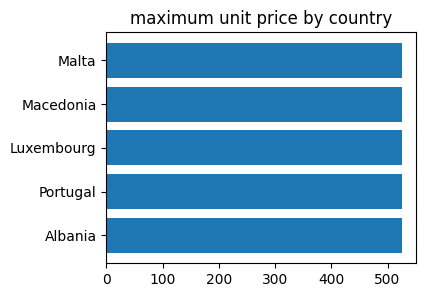

In [15]:
# نستعمل groupby دائما مع اداة aggregation
max_cost_by_country = df.groupby('Country')['Unit Cost'].max().sort_values(ascending=False).head(5)
print(max_cost_by_country)
plt.figure(figsize=(4,3))
plt.barh(max_cost_by_country.index, max_cost_by_country.values)
plt.title('maximum unit price by country')

Country
Albania     31.79
Portugal    31.79
Ukraine     31.79
Monaco      31.79
Croatia     31.79
Germany     31.79
Poland      31.79
Macedonia    6.92
Malta        6.92
Moldova      6.92
Name: Unit Cost, dtype: float64


Text(0.5, 1.0, 'minimum unit price by country')

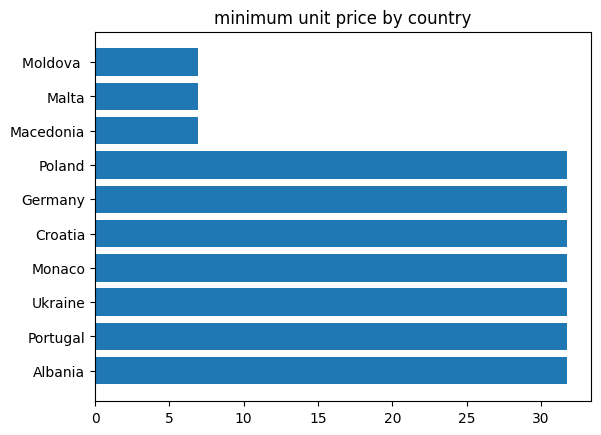

In [16]:
# نستعمل groupby دائما مع اداة aggregation
min_cost_by_country = df.groupby('Country')['Unit Cost'].min().sort_values(ascending=False).head(10)
print(min_cost_by_country)
plt.barh(min_cost_by_country.index, min_cost_by_country.values)
plt.title('minimum unit price by country')

In [17]:
# lets find out sales by month

# first lets make a month column extracting it from the order date

df['Order Date'].head()

df['Order Date'].dt.month_name().head() # -> now we have months name of the order date

# i can use that in aggregation (التجميع)
# df['month'] = 

df['month'] = df['Order Date'].dt.month_name()

# now another column for month ordering

df['month_num'] = df['Order Date'].dt.month

df[['Order Date', 'month', 'month_num']]


,Order Date,month,month_num
0,2011-09-12,September,9
1,2013-10-14,October,10
2,2014-08-13,August,8
3,2010-10-31,October,10
4,2016-09-28,September,9
...,...,...,...
1325,2014-01-14,January,1
1326,2014-04-14,April,4
1327,2015-11-09,November,11
1328,2012-05-09,May,5


    month_num      month  Total Revenue
0           1    January 157,903,881.67
1           2   February 141,544,945.25
2           3      March 170,692,280.05
3           4      April 114,807,392.50
4           5        May 157,728,838.17
5           6       June 166,083,474.31
6           7       July 155,947,385.47
7           8     August 117,205,903.92
8           9  September 127,324,498.78
9          10    October 107,832,960.98
10         11   November 139,455,445.82
11         12   December 147,095,391.19


<BarContainer object of 12 artists>

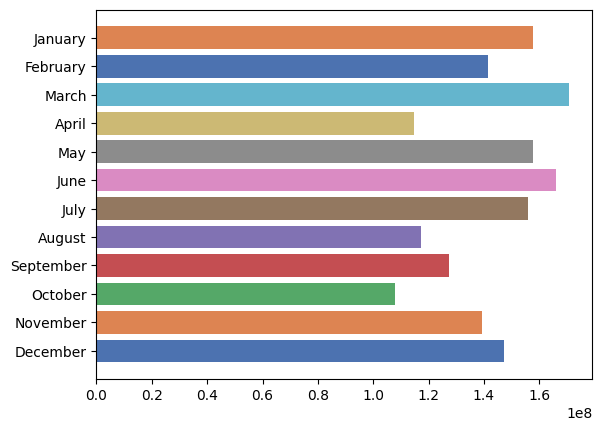

In [36]:
# now lets aggregate the month column with the total revenue
monthly_revenue = df.groupby(['month_num','month'])['Total Revenue'].sum().reset_index()
print(monthly_revenue)
monthly_revenue = monthly_revenue.sort_values('month_num', ascending=False)
plt.barh(monthly_revenue['month'], monthly_revenue['Total Revenue'] , color=sns.color_palette('deep'))
